In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import eikon as ek
import configparser as cp
from eikon_rics_lists import DA_HH_RICS, SSP_RICS #import rics list for Wholesale prices 

# Load the parquet file
df = pd.read_parquet("training_data.parquet")
print(df['delivery_ts'].min())

from pathlib import Path
cfg = cp.ConfigParser()
# Find eikon.cfg whether notebook is run from project root or data/
cfg_path = Path("eikon.cfg") if Path("eikon.cfg").is_file() else Path("data/eikon.cfg")
cfg.read(cfg_path)
if not cfg.has_section("eikon") or not cfg.has_option("eikon", "app_id"):
    raise KeyError(f"eikon.cfg at {cfg_path.resolve()} must contain [eikon] and app_id = <your key>.")
ek.set_app_key(cfg["eikon"]["app_id"])

ric = "EPXGBAUCD1H01H1"
ts = ek.get_timeseries(ric, start_date="2021-01-01", end_date="2021-01-10", fields=["CLOSE"])
print(ts)

2021-01-01 00:00:00
None


In [19]:
from data_loader import get_timeseries_chunked
import eikon as ek, configparser as cp
from pathlib import Path

cfg = cp.ConfigParser()
cfg.read(Path("eikon.cfg"))
ek.set_app_key(cfg["eikon"]["app_id"])

ts = get_timeseries_chunked("EPXGBAUCD1H01H1", "2021-01-01", "2023-01-01")
print(ts.shape, ts.index.min(), ts.index.max())

(272, 1) 2021-04-01 00:00:00 2022-11-30 00:00:00


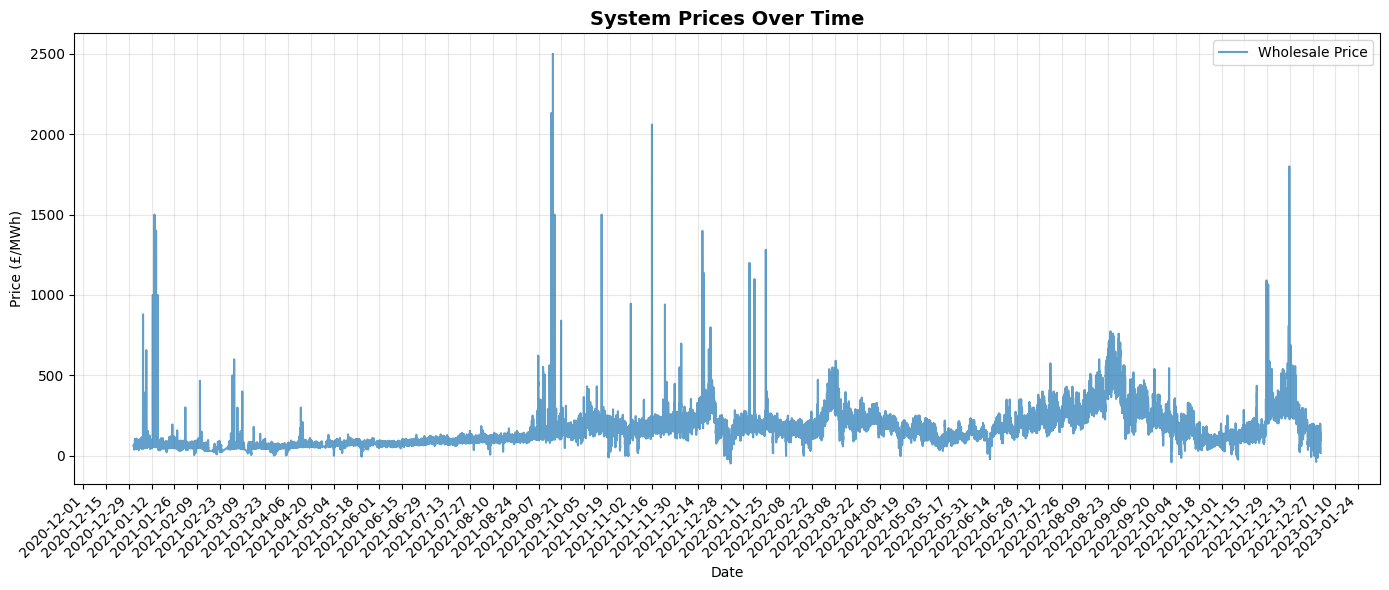

In [7]:
# Plot 1: System Prices Over Time
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df['delivery_ts'], df['da_price_gbp_mwh'], label='Wholesale Price', alpha=0.7, linewidth=1.5)
ax.set_xlabel('Date')
ax.set_ylabel('Price (£/MWh)')
ax.set_title('System Prices Over Time', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()


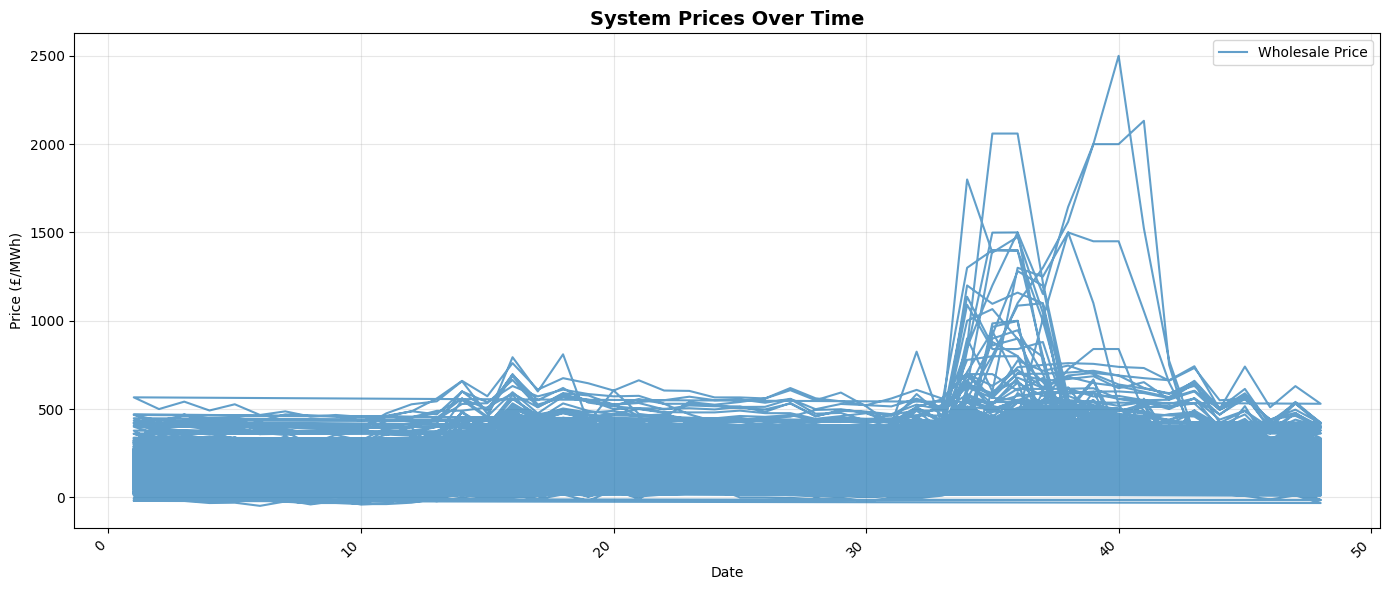

In [ ]:
# Plot 1: System Prices Over Time
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df['tau'], df['da_price_gbp_mwh'], label='Wholesale Price', alpha=0.7, linewidth=1.5)
ax.set_xlabel('Date')
ax.set_ylabel('Price (£/MWh)')
ax.set_title('System Prices Over Time', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()


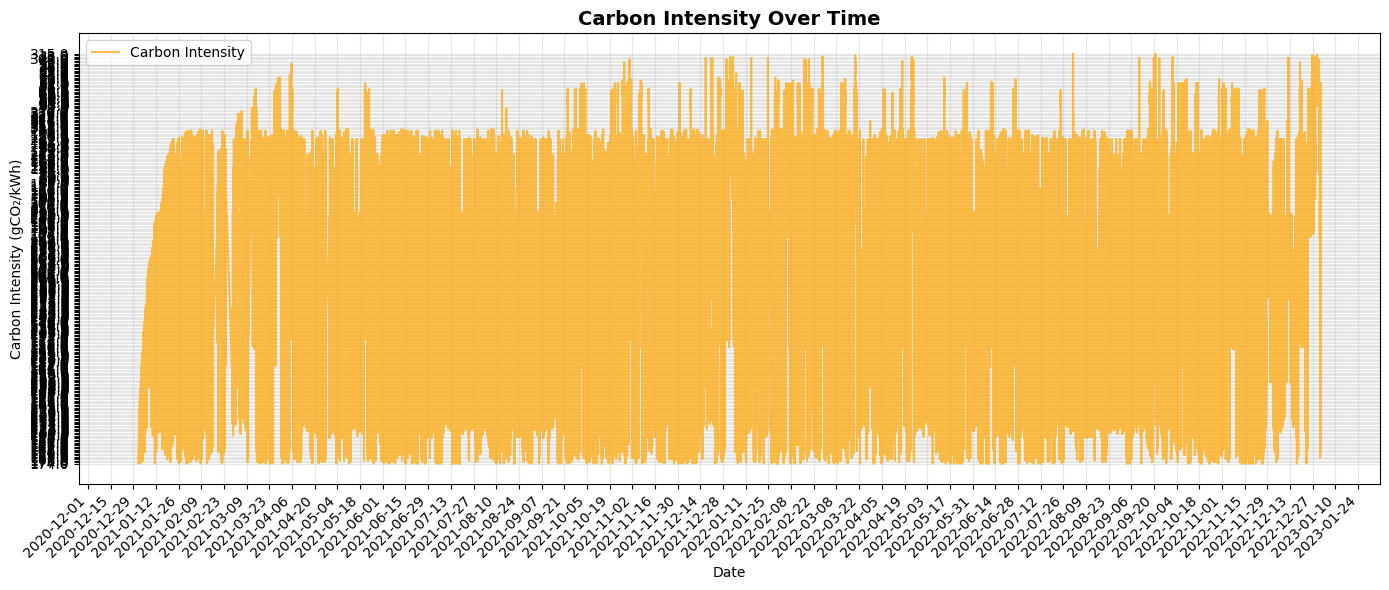

In [6]:
# Plot 2: Carbon Intensity Over Time
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df['delivery_ts'], df['carbon_gco2_kwh'], label='Carbon Intensity', 
        color='orange', alpha=0.7, linewidth=1.5)
ax.set_xlabel('Date')
ax.set_ylabel('Carbon Intensity (gCO₂/kWh)')
ax.set_title('Carbon Intensity Over Time', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()


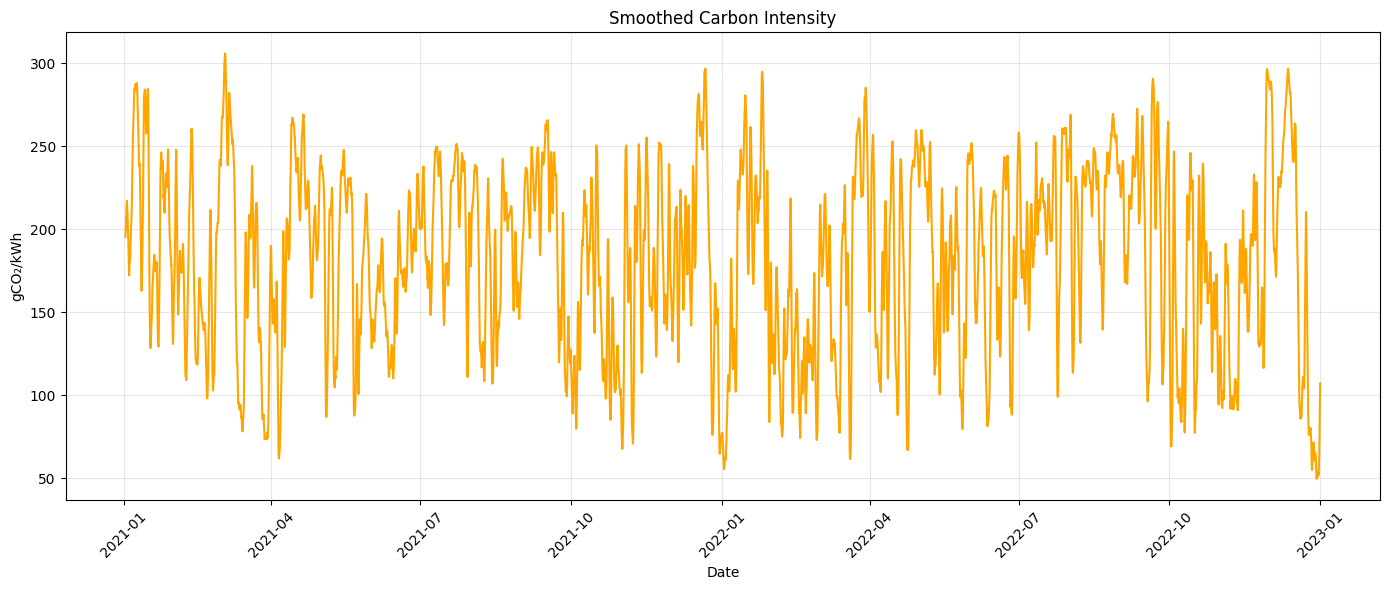

In [6]:
df['ci_smooth'] = df['carbon_gco2_kwh'].rolling(48).mean()  # 1 day window

plt.figure(figsize=(14,6))
plt.plot(df['timestamp'], df['ci_smooth'], color="orange")
plt.title("Smoothed Carbon Intensity")
plt.xlabel("Date")
plt.ylabel("gCO₂/kWh")
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()